In [282]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hyperparams Constants

In [300]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 256,
    'dim_mults':(1,4,8), # Dimension multipliers for hidden layers of the model
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 0,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 500,
    'n_worlds': 10,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
}

# Dataloader

In [301]:
from dataset import RobotPathDataset

In [302]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [303]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

world_indx: 505, world_distance_field_images: torch.Size([64, 64])
world_indx: 545, world_distance_field_images: torch.Size([64, 64])
world_indx: 720, world_distance_field_images: torch.Size([64, 64])
world_indx: 825, world_distance_field_images: torch.Size([64, 64])
world_indx: 826, world_distance_field_images: torch.Size([64, 64])
data shape: torch.Size([2000, 128, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:5, samples: 2000
 sample shape torch.Size([128, 2]) with 2000 samples


In [304]:

np.unique(dataset.worlds_indx)

array([505, 545, 720, 825, 826], dtype=int64)

In [305]:
denormalized_sample = normalizer.denormalize(sample['path'])
denormalized_sample

tensor([[2.0294, 5.5576],
        [2.0524, 5.4883],
        [2.0753, 5.4190],
        [2.0983, 5.3497],
        [2.1212, 5.2804],
        [2.1441, 5.2111],
        [2.1671, 5.1417],
        [2.1900, 5.0724],
        [2.2130, 5.0031],
        [2.2370, 4.9341],
        [2.2610, 4.8651],
        [2.2851, 4.7961],
        [2.3092, 4.7272],
        [2.3333, 4.6582],
        [2.3574, 4.5892],
        [2.3815, 4.5202],
        [2.4056, 4.4512],
        [2.4278, 4.3816],
        [2.4496, 4.3119],
        [2.4714, 4.2422],
        [2.4933, 4.1725],
        [2.5151, 4.1027],
        [2.5369, 4.0330],
        [2.5587, 3.9633],
        [2.5805, 3.8935],
        [2.6049, 3.8247],
        [2.6301, 3.7561],
        [2.6553, 3.6875],
        [2.6805, 3.6190],
        [2.7057, 3.5504],
        [2.7309, 3.4818],
        [2.7561, 3.4133],
        [2.7813, 3.3447],
        [2.8073, 3.2764],
        [2.8339, 3.2084],
        [2.8604, 3.1403],
        [2.8869, 3.0722],
        [2.9134, 3.0042],
        [2.9

In [306]:
WORLD_IMG = sample['world_img'] 

In [ ]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [ ]:
sample_batch['world_indx'].shape

torch.Size([32])

# Archtechture

### encoder

In [ ]:
from model import WorldIndexEmbeder, FlattenEmbeder

In [ ]:
embedding_dim = CONFIG['representation_dim']
# Define the model
sample_input = sample['world_distance_field_img']
encoder = FlattenEmbeder(input_sample=sample_input, embedding_dim=embedding_dim, normalizer=None, num_of_hidden_layers=CONFIG['embeder_num_of_hidden_layers'])
encoder

FlattenEmbeder(
  (embedding): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): SELU()
  )
)

### Model and diffusion

In [ ]:
from model import Diffusion, TemporalUnet

In [ ]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['n_waypoints'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, device=device)

2
[ models/temporal ] Channel dimensions: [(2, 512), (512, 1024)]
[(2, 512), (512, 1024)]


In [ ]:
model.to(device);
model.device

device(type='cuda', index=0)

In [ ]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [ ]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['path'], timesteps)
assert y.shape == (batch_size, CONFIG['n_waypoints'], 2)
y.shape

RuntimeError: Given groups=1, weight of size [256, 256, 5], expected input[32, 512, 128] to have 256 channels, but got 512 channels instead

In [ ]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch['path'],timesteps)
x_t.shape, noise.shape

(torch.Size([32, 128, 2]), torch.Size([32, 128, 2]))

In [ ]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([33, 99, 54, 13, 86], device='cuda:0')


# Training

In [ ]:
# write training loop 
import torch.optim as optim
import torch.nn as nn


In [ ]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name='path-dataset-multiworld=10-distancefield-embedder')
logging_manager.log_config(CONFIG);

INFO:LoggingManager:Configuration:
INFO:LoggingManager:representation_dim: 256
INFO:LoggingManager:dim_mults: (1, 2, 4, 8)
INFO:LoggingManager:embeder_num_of_hidden_layers: 0
INFO:LoggingManager:batch_size: 32
INFO:LoggingManager:num_epochs: 100
INFO:LoggingManager:learning_rate: 0.001
INFO:LoggingManager:optimizer: <class 'torch.optim.adam.Adam'>
INFO:LoggingManager:noise_steps: 100
INFO:LoggingManager:normalize: True
INFO:LoggingManager:normalizer: <dataset.RobotPathDataset.normalizer.MinMaxFeatureNormalizer object at 0x00000150C2C76500>
INFO:LoggingManager:encoder_normalizer: <dataset.RobotPathDataset.normalizer.MinMaxFeatureNormalizer object at 0x00000150C2C74850>
INFO:LoggingManager:scheduler: <class 'torch.optim.lr_scheduler.ExponentialLR'>
INFO:LoggingManager:ema: <model.models.EMA object at 0x00000150C2C77730>
INFO:LoggingManager:scheduler_gamma: 0.999
INFO:LoggingManager:n_paths_per_world: 500
INFO:LoggingManager:n_worlds: 10
INFO:LoggingManager:n_waypoints: 128


Logging to logs\path-dataset-multiworld=10-distancefield-embedder/19h-43m-19-05-2024/logs.log


In [ ]:
# log the model and input sample 
input_tensor = sample_batch['path']
# logging_manager.tb_log_graph(model)

### Set up validation and plotting function

In [ ]:
def plot_diffusions(intermediates, world_imgs=None, normalizer=None, max_plots=8):
    # choose 5 intermediates equally spaced with the last one being at the end indexand 
    intermediates_indx_to_draw = [0, len(intermediates) //4 ,len(intermediates)//2, (3* len(intermediates) ) // 4,len(intermediates)-1]
    if normalizer:
        intermediates = normalizer.denormalize(intermediates, is_numpy=True)
    intermediates = intermediates[intermediates_indx_to_draw]
    intermediates = intermediates.transpose(1,0,2,3)
    if intermediates.shape[0] > max_plots:
        intermediates = intermediates[:max_plots]
    number_of_samples = intermediates.shape[0]
    number_of_steps = intermediates.shape[1]
    fig , ax = plt.subplots(number_of_samples,number_of_steps, figsize=(20,20))
    for i, sample in enumerate(intermediates):
        for j, step in enumerate(sample): 
            ax[i, j].plot(step[:, 0], step[:, 1], 'o-', label='l', color='red', alpha=0.8)
            if world_imgs is not None:
                ax[i, j].imshow(world_imgs[i].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
             # put 1st point in green and last point in red
            ax[i, j].plot(step[0, 0], step[0, 1], 'o-', label='start', color='green')
            ax[i, j].plot(step[-1, 0], step[-1, 1], 'o-', label='end', color='yellow')
    plt.tight_layout()
    return fig

# plot = plot_diffusions(intermediates, world_img=WORLD_IMG)
# logging_manager.tb_log_figure(plot, 'diffusion_samples')

In [ ]:
def plot_noise_and_predicted_noise(sample, noise, predicted_noise, timesteps, normalizer=None, max_plots=8):

    # if any of the inputs are in the GPU move them to CPU
    if sample.is_cuda:
        sample = sample.clone().cpu().detach().numpy()
    if noise.is_cuda:
        noise = noise.clone().cpu().detach().numpy()
    if predicted_noise.is_cuda:
        predicted_noise = predicted_noise.clone().cpu().detach().numpy()
    if timesteps.is_cuda:
        timesteps = timesteps.clone().cpu().detach().numpy()

    # get per sample differnce betwen noise and predicted noise MSE
    mse_per_sample = np.mean(np.square(noise - predicted_noise), axis=(1, 2))
    sample_plus_noise = sample + noise
    sample_plus_predicted_noise = sample + predicted_noise
    # denormalize the samples
    if normalizer:
        sample = normalizer.denormalize(sample, is_numpy=True)
        sample_plus_noise = normalizer.denormalize(sample_plus_noise, is_numpy=True)
        sample_plus_predicted_noise = normalizer.denormalize(sample_plus_predicted_noise, is_numpy=True)
    if sample.shape[0] > max_plots:
        sample = sample[:max_plots]
        sample_plus_noise = sample_plus_noise[:max_plots]
        sample_plus_predicted_noise = sample_plus_predicted_noise[:max_plots]
        mse_per_sample = mse_per_sample[:max_plots]
        timesteps = timesteps[:max_plots]
    n_cols = 2
    n_rows = sample.shape[0] // n_cols 
    fig, ax = plt.subplots(n_rows , n_cols, figsize=(20, 20))
    for i in range(n_rows):
        for j in range(n_cols):
            ax[i, j].plot(sample[j*n_cols + i, :, 0], sample[j*n_cols + i, :, 1], 'o-', label='input', color='blue')
            ax[i, j].plot(sample_plus_noise[j*n_cols + i, :, 0], sample_plus_noise[j*n_cols + i, :, 1], 'o-', label=f'noised', color='green', alpha=0.5)
            ax[i, j].plot(sample_plus_predicted_noise[j*n_cols + i, :, 0], sample_plus_predicted_noise[j*n_cols + i, :, 1], 'o-', label=f'predicted', color='red', alpha=0.5)
            ax[i, j].set_title(f'MSE={mse_per_sample[j*n_cols + i]:.3f}, t={timesteps[j*n_cols + i]}')  # Title for each subplot

    plt.legend()
    return fig


# Train 

In [ ]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"D:\Desktop\ADLR\RobotPathData\logs\path-dataset-multiworld=10-distancefield-embedder\15h-08m-18-05-2024\model-epoch_16-loss_0.043-time_15h-43m-18-05-2024"

In [ ]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), lr=CONFIG['learning_rate'])
scheduler = CONFIG['scheduler'](optimizer, gamma=CONFIG['scheduler_gamma'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')

for epoch in range(CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader), leave=True)
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img, batch_world_distance_field_img = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img'], batch_and_info['world_distance_field_img']
        
        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        cond = batch_world_distance_field_img.to(device)
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond)
        
        # print the encoder weights to make sure it is training 

        loss = nn.MSELoss()(noise, pred_noise)
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        pbar.set_postfix({'loss': loss.item()})
        if i % 1000 == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise', step= i + epoch * len(dataloader))
                    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()


    if epoch% 2 == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)  
        # sample model
        samples, intermediates = diffusion.sample(model,5)
        random_world_indx= torch.randint(0, CONFIG['n_worlds'], (1,), device=device)
        random_world_img = dataset.world_image_from_world_indx(random_world_indx)
        plot = plot_diffusions(intermediates,  normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples', step=epoch) 
        # sample ema model
        samples, intermediates = diffusion.sample(ema_model,5)
        plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples_ema', step=epoch)
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)# create constraints dict 
        for k in range(2):
            last_index_for_waypoints = CONFIG['n_waypoints'] - 1
            constraints = {
                0: torch.tensor([0, 0], device=device),
                last_index_for_waypoints: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_distance_field_img.to(device)
            world_imgs = batch_world_img
            logging_manager.log_message(f'Generating samples from edge to edge with worlds {batch_world_indx}')
            samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch);

print('Finished Training')    

  9%|▉         | 7/78 [00:34<05:48,  4.90s/it, loss=1]   


KeyboardInterrupt: 

In [ ]:
constraints = {
    0: torch.tensor([0, 0], device=device),
    99: torch.tensor([9, 9],device=device),
}
# choose 1 random world
random_world_indx= 5
# sample n samples from this world
n=5
world_distance_field_img = dataset[random_world_indx]['world_distance_field_img']
world_img = dataset[random_world_indx]['world_img']
# create a batch of 5 of this world
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape

torch.Size([5, 64, 64])

In [ ]:
world_imgs = [world_img for i in range(n)]
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])
logging_manager.tb_log_figure(plot, f'sampling with constraints', step=1)

99it [00:01, 50.19it/s]


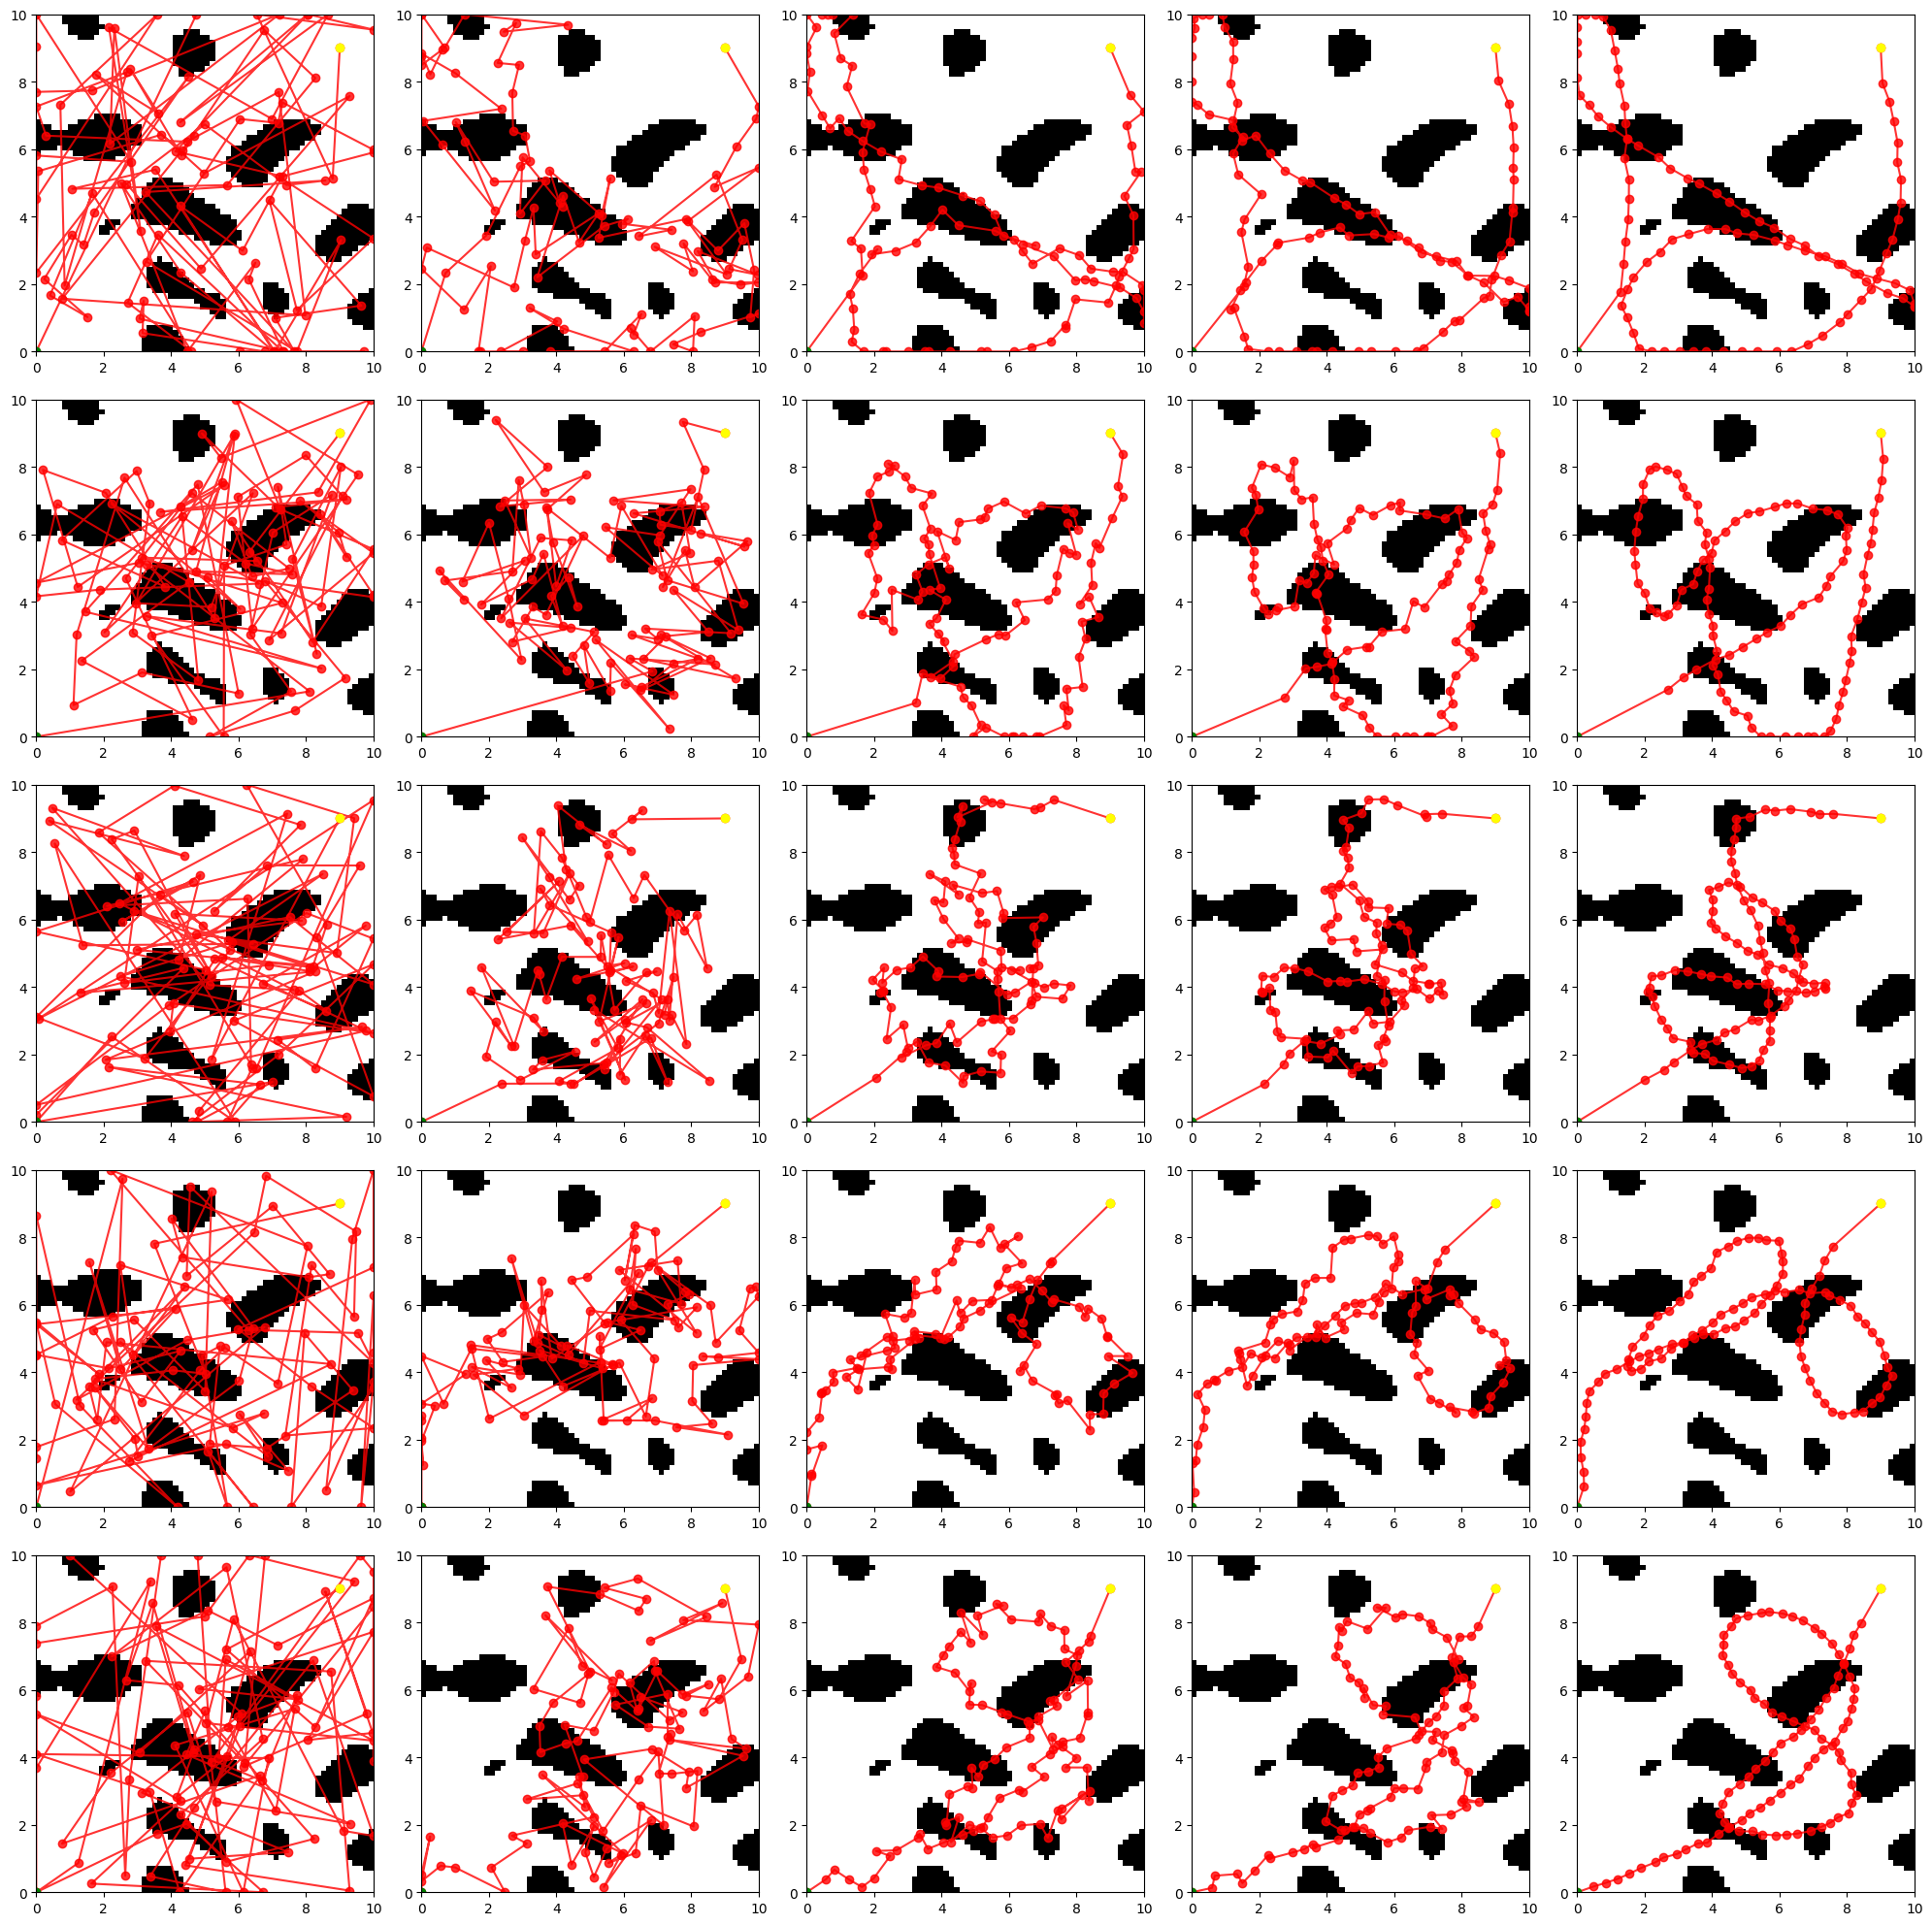

In [ ]:
plot

In [ ]:
# Get a real path from the dataset and use it's start and end point as constraints then plot both besides each other
random_indx = random.randint(0, len(dataset))
item = dataset.get_og_item(random_indx)
real_path = item['path']
starting_point = real_path[0]
end_point = real_path[-1]
world_img = item['world_img']
world_imgs = [world_img for i in range(n)]
world_distance_field_img = item['world_distance_field_img']
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape , random_indx

(torch.Size([5, 64, 64]), 6064)

99it [00:02, 47.82it/s]


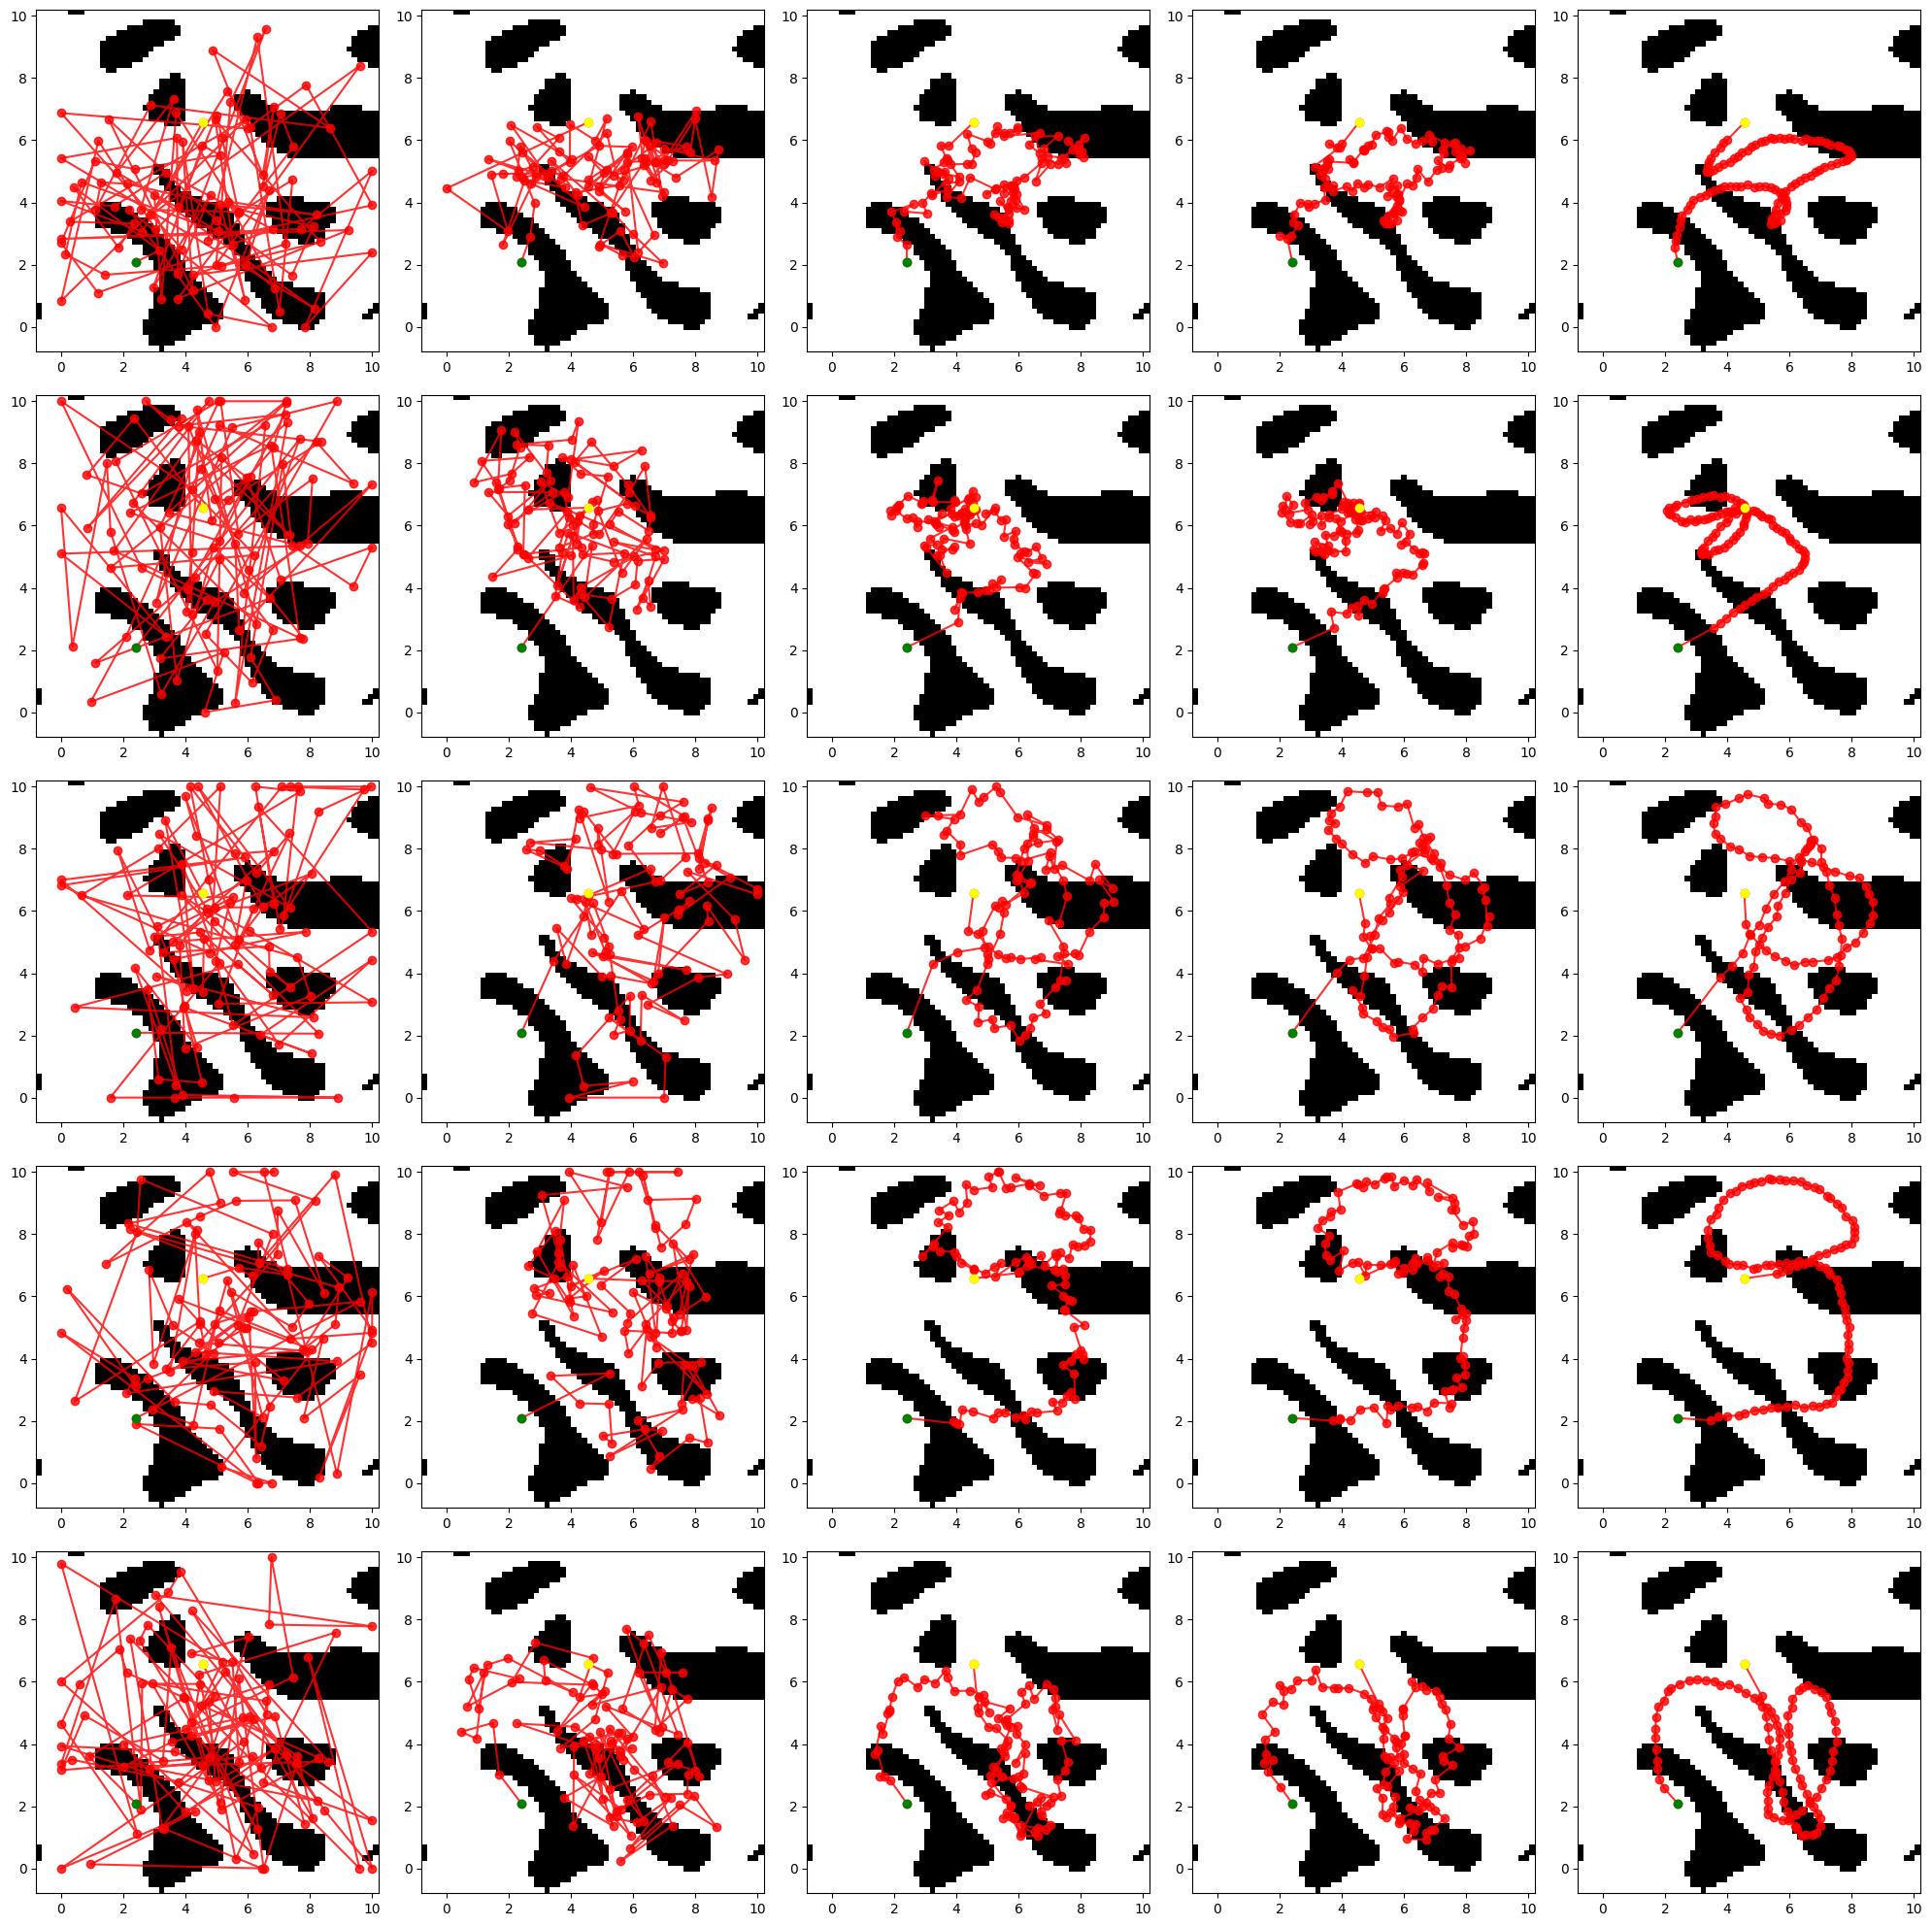

In [ ]:
constraints = {
    0: starting_point,
    99: end_point,
}
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])

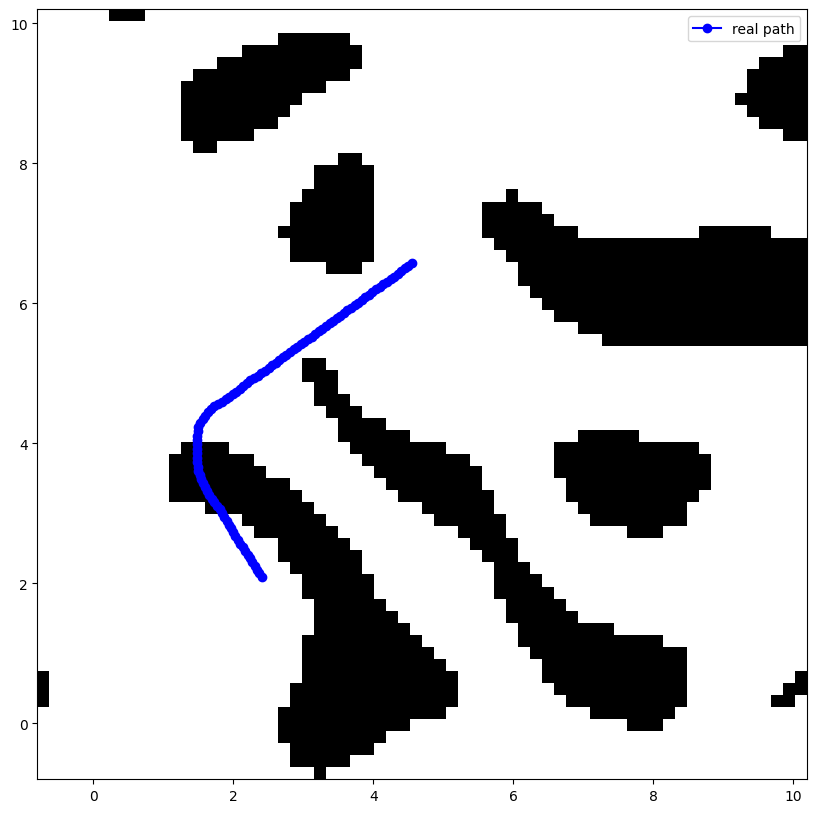

In [ ]:
# plot the real path
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
real_path = real_path.cpu().detach().numpy()
ax.plot(real_path[:, 0], real_path[:, 1], 'o-', label='real path', color='blue')
ax.imshow(world_img.T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
plt.legend()

In [ ]:
logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

In [ ]:
# # Save final model
torch.save(model.state_dict(), 'model.pth')

# Sample Model

In [ ]:
# load checkpoint
model, _, _, _, _, = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=r'D:\Desktop\ADLR\RobotPathData\logs\dummy-path-dataset\14h-36m-11-05-2024\model-epoch_39-loss_0.121-time_16h-48m-11-05-2024')

99it [00:01, 50.69it/s]


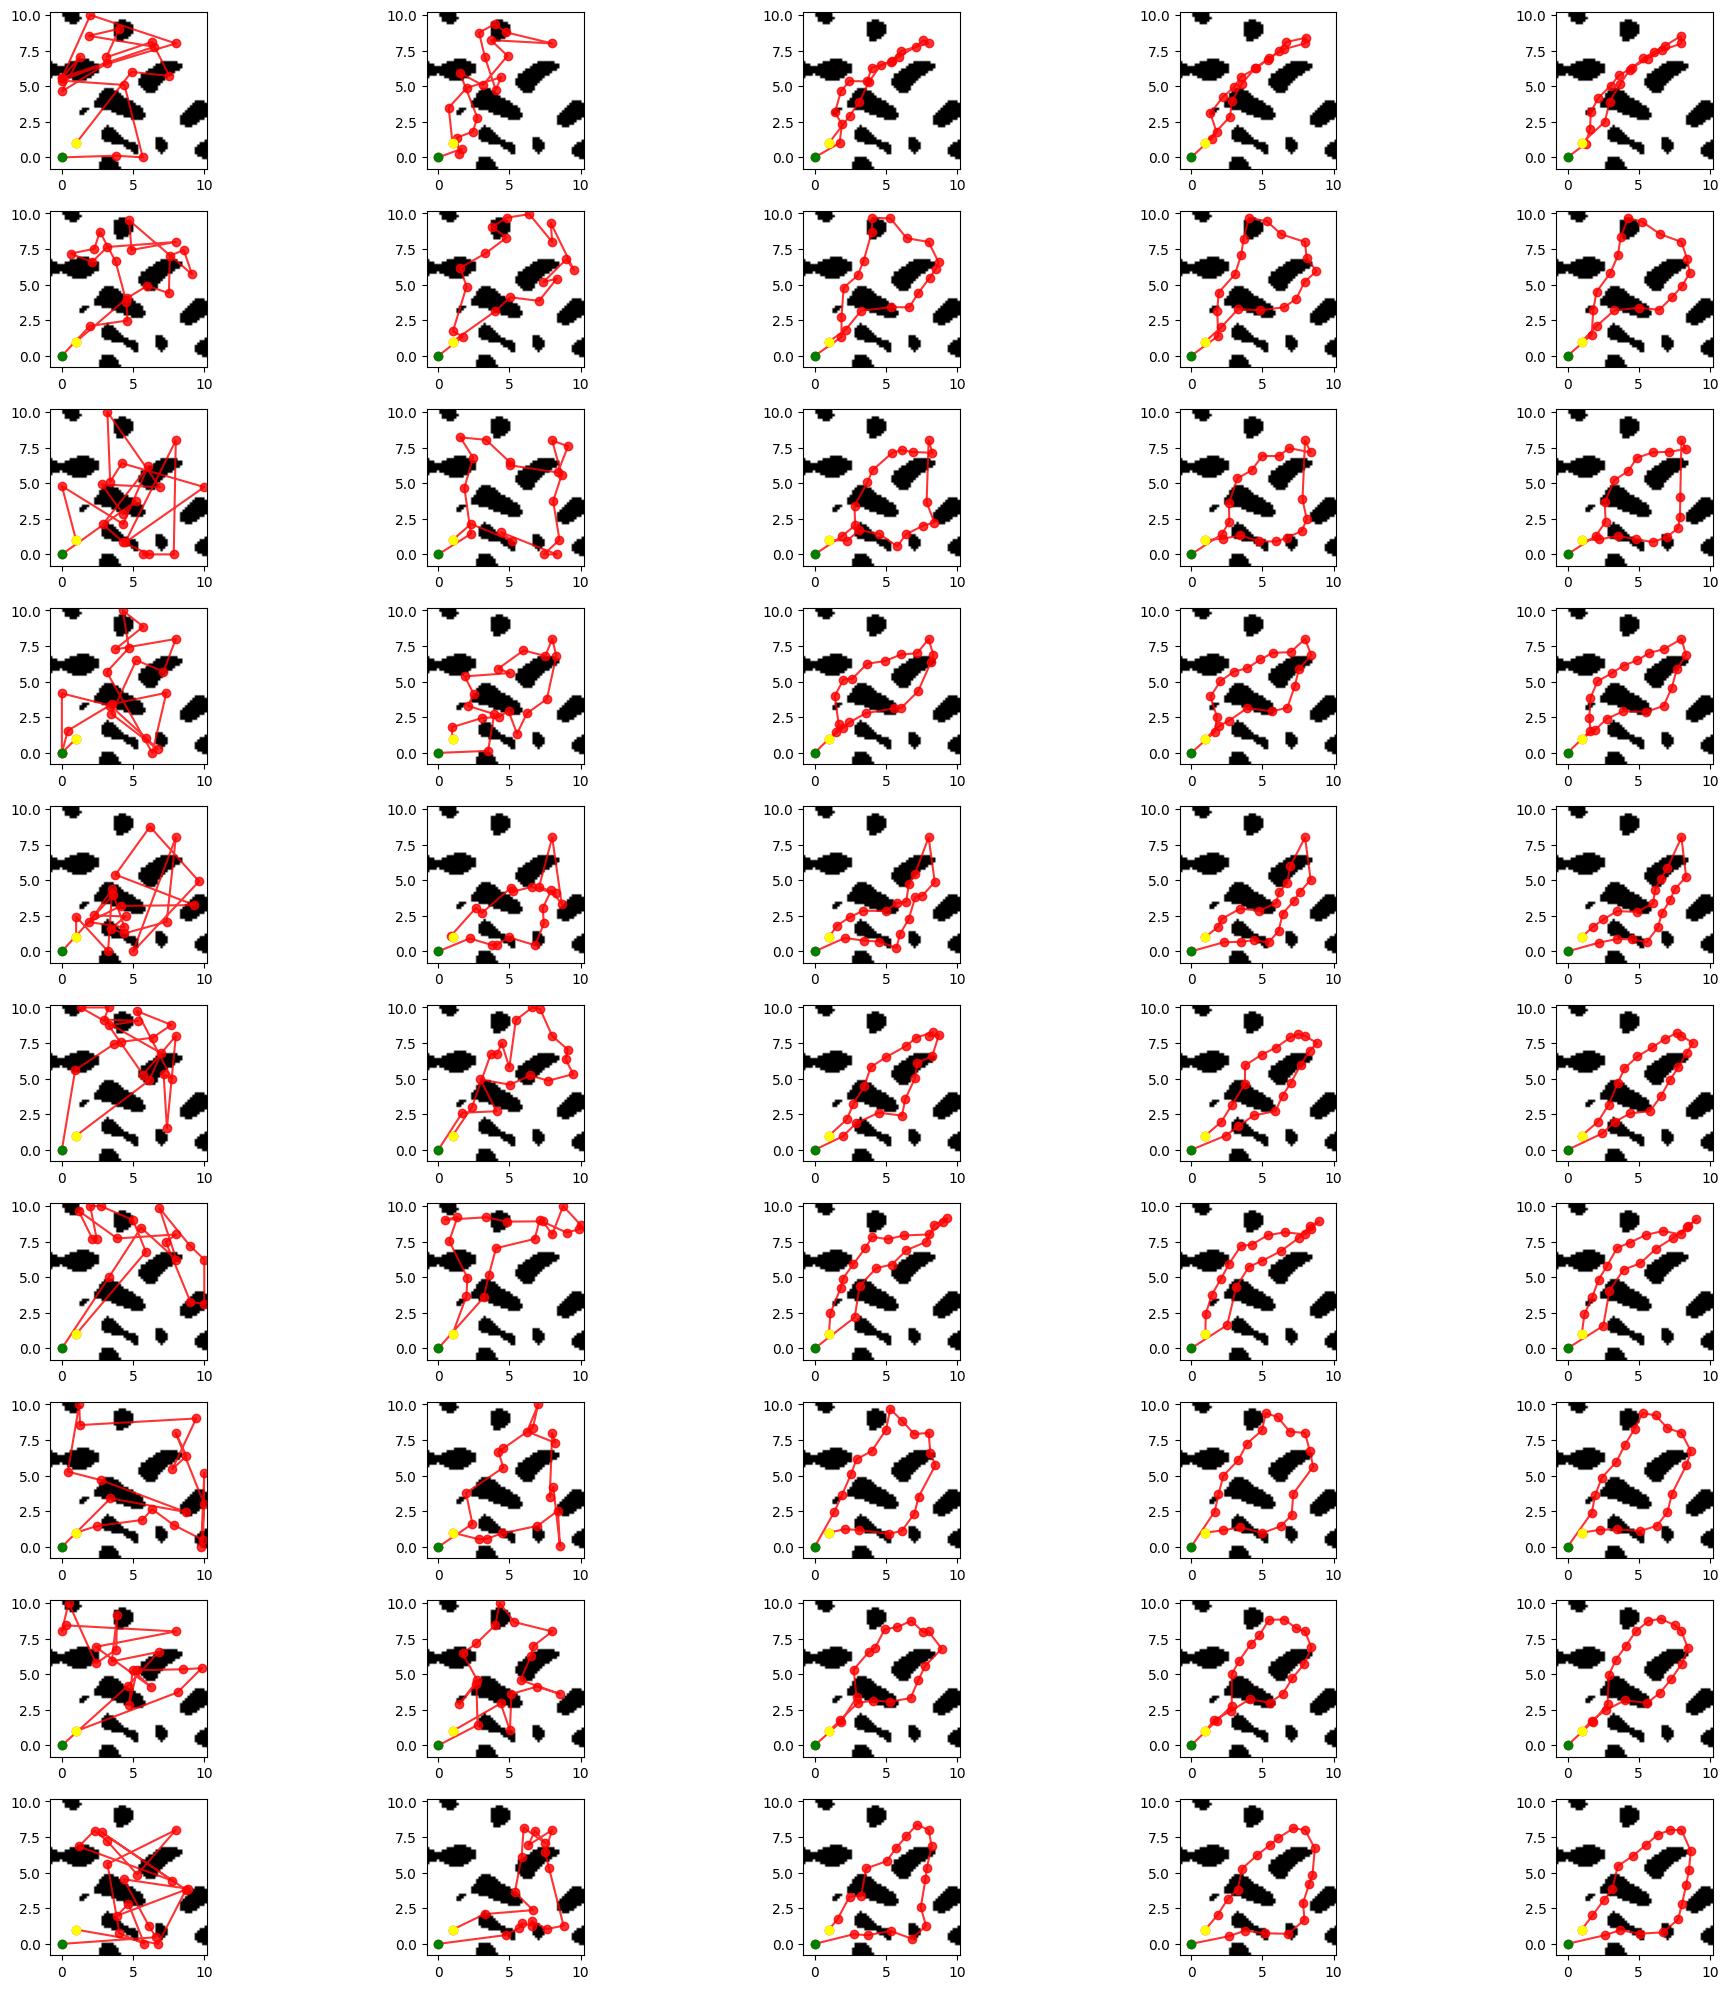

In [ ]:
# create constraints dict 
constraints = {
    0: torch.tensor([0, 0], device=device),
    10: torch.tensor([8, 8],device=device),
    19: torch.tensor([1, 1],device=device),
}
# sample from final model
samples, intermediates = diffusion.sample_with_constraints(model, 10, constraints, normalizer=CONFIG['normalizer'])
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])